# 🏗️ Terrain Vente — Pipeline v4 (Données enrichies)

**Améliorations v4 vs v3 :**
- `kw_facade` : corrélation 0.231 avec log(prix/m²) — nouveau signal fort
- `kw_projet` : corrélation 0.170 avec log(prix) — terrains avec projet = plus grands
- `statut_titre` : TF / Melkiya / non-spécifié (3 catégories vs binaire)
- `log_surface` cubique et interactions surface×zone améliorées
- Descriptions `marrakechrealty` + `milkiya` mieux exploitées

In [1]:
# import os, sys, json, joblib, warnings, re

# import sys
# import os

# sys.path.append(
#     os.path.abspath("../../pipeline")
# )

# from pip_terrain import (
#     parse_price,
#     parse_surface,
#     extract_zone,
#     load_data,
#     train_model,
#     predict_price
# )

## 0. Imports

In [2]:
import os, sys, json, joblib, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath("../../pipeline"))

RAW_PATH   = "../../data/marrakech_immo_vente/terrain_vente.csv"
CLEAN_PATH = "../../data/cleaned_data/vente/terrain_vente_final.csv"
MODEL_PATH = "../../model_training/models/xgb_terrain_vente.pkl"
META_PATH  = "../../model_training/models/xgb_terrain_vente_metadata.json"
print("✅ Imports OK")


/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK


## 1. Chargement & Cleaning

In [3]:
# ── Cell 4 — Chargement & nettoyage de base ──────────────────
import re, numpy as np, pandas as pd

df = pd.read_csv(RAW_PATH)
print(f"Brut : {df.shape}")

# Terrains uniquement
df = df[df["type_bien"].isin(["Terrain", "Vente Terrain", "terrain"])].copy()
print(f"Terrains : {len(df)}")

# ── Parse prix_num depuis colonne "prix" texte ──
def _parse_prix(s):
    if pd.isna(s): return np.nan
    s = str(s).replace(" ","").replace("\xa0","").replace(".","").replace(",",".")
    m = re.search(r"\d+(?:\.\d+)?", s)
    try: return float(m.group()) if m else np.nan
    except: return np.nan

df["prix_num"]    = df["prix"].apply(_parse_prix)
df["surface_num"] = pd.to_numeric(df["surface"], errors="coerce")

# ── Déduplication (maintenant que prix_num et surface_num existent) ──
df = df.drop_duplicates(subset=["prix_num", "surface_num", "localisation"]).copy()
print(f"Après dédup : {len(df)}")

# EUR → MAD
EUR_TO_MAD = 10.8
eur_mask = df["prix"].str.contains("EUR", na=False)
df.loc[eur_mask, "prix_num"] *= EUR_TO_MAD

# Filtres
df = df[df["prix_num"].notna() & (df["prix_num"] > 0)].copy()
df = df[df["surface_num"].notna() & df["surface_num"].between(50, 500_000)].copy()
df["_pm2"] = df["prix_num"] / df["surface_num"]
df = df[df["_pm2"].between(50, 50_000)].copy()
df.drop(columns=["_pm2"], inplace=True)

# Quantiles prix
log_p = np.log(df["prix_num"])
df = df[(log_p >= log_p.quantile(0.01)) & (log_p <= log_p.quantile(0.99))].copy()
df.reset_index(drop=True, inplace=True)
print(f"Après filtres : {len(df)} lignes")
print(f"prix médian   : {df['prix_num'].median():,.0f} MAD")
print(f"surface médiane: {df['surface_num'].median():.0f} m²")
print(f"pm² médian    : {(df['prix_num']/df['surface_num']).median():,.0f} MAD/m²")

Brut : (2256, 13)
Terrains : 919
Après dédup : 864
Après filtres : 328 lignes
prix médian   : 2,200,000 MAD
surface médiane: 1246 m²
pm² médian    : 1,531 MAD/m²


In [4]:
df.head(5)

,id,titre,prix,localisation,type_bien,surface,chambres,salles_bain,description,agence,url,source,telephone,prix_num,surface_num
0,632190,Terrain à vendre 1 950 000 dh 492 m² - Autre -...,1 950 000 DH,Marrakech - Autre,Terrain,492,NaN,NaN,NaN,NaN,https://agenz.ma/fr/annonces/immo-marrakech/ve...,agenz,NaN,1950000.0,492.0
1,380229,Terrain à vendre 2 000 000 dh 400 m² - Amelkis...,2 000 000 DH,Marrakech - Amelkis,Terrain,400,NaN,NaN,NaN,NaN,https://agenz.ma/fr/annonces/immo-marrakech/ve...,agenz,NaN,2000000.0,400.0
2,231619,Terrain à vendre 2 500 000 dh 499 m² - Autre -...,2 500 000 DH,Marrakech - Autre,Terrain,499,NaN,NaN,NaN,NaN,https://agenz.ma/fr/annonces/immo-marrakech/ve...,agenz,NaN,2500000.0,499.0
3,8300784,Terrain à vendre 850 000 dh 151 m² - Hay Al Ba...,850 000 DH,Marrakech - Hay Al Bahja,Terrain,151,NaN,NaN,NaN,NaN,https://agenz.ma/fr/annonces/immo-marrakech/ve...,agenz,NaN,850000.0,151.0
4,886374,Terrain à vendre 3 068 000 dh 767 m² - Route d...,3 068 000 DH / mois,Marrakech - Route d'Amizmiz,Terrain,767,NaN,NaN,NaN,NaN,https://agenz.ma/fr/annonces/immo-marrakech/ve...,agenz,NaN,3068000.0,767.0


In [5]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns


# plt.style.use("ggplot")

# pd.set_option("display.max_columns", None)

# print("Imports OK")


# # =========================================================
# # 3. LOAD DATA
# # =========================================================

# # DATA_PATH = "terrain_vente.csv"

# df = load_data(RAW_PATH)

# print(df.shape)

# df.head()

In [6]:

# print("=" * 60)
# print("INFO DATASET")
# print("=" * 60)

# display(df.info())

# display(df.describe())

In [7]:
# # =========================================================
# # 5. MISSING VALUES
# # =========================================================

# missing = (
#     df.isnull()
#     .sum()
#     .sort_values(ascending=False)
# )

# display(missing[missing > 0])

In [8]:
# # =========================================================
# # 6. TARGET ANALYSIS
# # =========================================================

# print("=" * 60)
# print("TARGET ANALYSIS")
# print("=" * 60)

# print("Prix moyen :", round(df["prix_num"].mean(), 0))
# print("Prix median :", round(df["prix_num"].median(), 0))

# print("PM2 moyen :", round(df["pm2"].mean(), 0))
# print("PM2 median :", round(df["pm2"].median(), 0))


In [9]:


# # =========================================================
# # 7. DISTRIBUTION PRIX
# # =========================================================

# plt.figure(figsize=(10, 5))

# df["prix_num"].hist(bins=60)

# plt.title("Distribution Prix")

# plt.xlabel("Prix")

# plt.ylabel("Count")

# plt.show()

In [10]:
# # =========================================================
# # 8. DISTRIBUTION PM2
# # =========================================================

# plt.figure(figsize=(10, 5))

# df["pm2"].hist(bins=60)

# plt.title("Distribution Prix/m²")

# plt.xlabel("PM2")

# plt.ylabel("Count")

# plt.show()

In [11]:
# # =========================================================
# # 9. LOG TARGET
# # =========================================================

# plt.figure(figsize=(10, 5))

# df["log_pm2"].hist(bins=60)

# plt.title("Distribution log(pm2)")

# plt.show()

In [12]:

# # =========================================================
# # 10. ZONES
# # =========================================================

# zone_counts = (
#     df["zone_clean"]
#     .value_counts()
# )

# display(zone_counts)

# plt.figure(figsize=(12, 5))

# zone_counts.plot(kind="bar")

# plt.title("Nombre annonces par zone")

# plt.show()

In [13]:
# # 11. PM2 PAR ZONE
# # =========================================================

# zone_pm2 = (
#     df.groupby("zone_clean")["pm2"]
#     .median()
#     .sort_values(ascending=False)
# )

# display(zone_pm2)

# plt.figure(figsize=(12, 5))

# zone_pm2.plot(kind="bar")

# plt.title("PM2 médian par zone")

# plt.ylabel("MAD / m²")

# plt.show()


In [14]:
# # =========================================================
# # 12. USAGE TERRAIN
# # =========================================================

# usage_counts = (
#     df["usage_terrain"]
#     .value_counts()
# )

# display(usage_counts)

# plt.figure(figsize=(8, 5))

# usage_counts.plot(kind="bar")

# plt.title("Usage terrain")

# plt.show()


In [15]:
# # =========================================================
# # 13. SURFACE ANALYSIS
# # =========================================================

# plt.figure(figsize=(10, 5))

# df["surface_num"].hist(bins=50)

# plt.title("Distribution Surface")

# plt.xlabel("m²")

# plt.show()


In [16]:

# # =========================================================
# # 14. SURFACE VS PRIX
# # =========================================================

# plt.figure(figsize=(8, 6))

# plt.scatter(

#     df["surface_num"],
#     df["prix_num"],

#     alpha=0.4
# )

# plt.xlabel("Surface")

# plt.ylabel("Prix")

# plt.title("Surface vs Prix")

# plt.show()


In [17]:
# # =========================================================
# # 15. SURFACE VS PM2
# # =========================================================

# plt.figure(figsize=(8, 6))

# plt.scatter(

#     df["surface_num"],
#     df["pm2"],

#     alpha=0.4
# )

# plt.xlabel("Surface")

# plt.ylabel("PM2")

# plt.title("Surface vs PM2")

# plt.show()


In [18]:
# # =========================================================
# # 16. CORRELATION NUMERIC
# # =========================================================
# import seaborn as sns

# numeric_cols = [

#     "surface_num",
#     "log_surface",
#     "pm2",
#     "prix_num",
# ]

# corr = df[numeric_cols].corr()

# display(corr)

# plt.figure(figsize=(8, 6))

# sns.heatmap(

#     corr,

#     annot=True,
#     cmap="coolwarm"
# )

# plt.title("Correlation Matrix")

# plt.show()


In [19]:
# # =========================================================
# # 17. KEYWORDS ANALYSIS
# # =========================================================

# kw_cols = [

#     "kw_constructible",
#     "kw_agricole",
#     "kw_immeuble",
#     "kw_golf"
# ]

# for col in kw_cols:

#     print("=" * 60)
#     print(col)
#     print("=" * 60)

#     display(

#         df.groupby(col)["pm2"]
#         .median()
#     )


In [20]:

# # =========================================================
# # 18. TRAIN MODEL
# # =========================================================

# model = train_model(df)


In [21]:
# # =========================================================
# # 19. TEST PREDICTIONS
# # =========================================================

# predict_price(

#     model,

#     surface=1000,

#     zone="Route_Ourika"
# )

# predict_price(

#     model,

#     surface=5000,

#     zone="Palmeraie"
# )

# predict_price(

#     model,

#     surface=300,

#     zone="Targa"
# )


In [22]:
# # =========================================================
# # 20. FEATURE IMPORTANCE
# # =========================================================

# feature_importance = pd.DataFrame({

#     "feature": model.feature_names_,
#     "importance": model.feature_importances_
# })

# feature_importance = feature_importance.sort_values(

#     by="importance",
#     ascending=False
# )

# display(feature_importance)

# plt.figure(figsize=(10, 6))

# plt.barh(

#     feature_importance["feature"],
#     feature_importance["importance"]
# )

# plt.title("Feature Importance")

# plt.gca().invert_yaxis()

# plt.show()


In [23]:
# # =========================================================
# # 21. SAVE CLEAN DATA
# # =========================================================

# df.to_csv(

#     "terrain_cleaned.csv",
#     index=False
# )

# print("Clean dataset saved.")



## 2. Feature Engineering

**Features textuelles enrichies v4 :**
- `kw_facade` (corr 0.231) — terrains avec façade = constructibilité confirmée
- `kw_projet` (corr 0.170) — terrains avec projet = meilleure localisation
- `statut_titre` — TF / Melkiya / non-spécifié (catégorielle)
- `kw_immeuble` (corr 0.267) — usage immeuble = prix/m² élevé
- `kw_agricole` (corr -0.340) — signal négatif fort

In [24]:
# Texte unifié
df["text_all"] = (
    df["description"].fillna("") + " " +
    df["titre"].fillna("") + " " +
    df["localisation"].fillna("")
).str.lower()

# Keywords v4 (tous les signaux utiles)
kw_dict = {
    "kw_immeuble"    : r"immeuble|r\+[0-9]|rez.de",
    "kw_agricole"    : r"agricole|agri\b|oliveraie|palmier|verger",
    "kw_golf"        : r"golf|amelkis",
    "kw_villa_zone"  : r"zone villa|lotissement villa",
    "kw_resid"       : r"résidentiel|zone résid",
    "kw_facade"      : r"façade|front de",          # nouveau v4
    "kw_projet"      : r"projet|promotion|programme", # nouveau v4
    "kw_constructible":r"constructible|à bâtir|permis",
    "kw_plat"        : r"terrain plat|nivelé|plat\b",
    "kw_urgent"      : r"urgent|à saisir|négociable",
    "kw_viabilise"   : r"viabili|raccord|eau.élect",
    "kw_industriel"  : r"industriel|zone indus",
}
for feat, pattern in kw_dict.items():
    df[feat] = df["text_all"].str.contains(pattern, regex=True, na=False).astype(int)

# Statut titre (catégorielle 3 classes)
df["kw_tf"]   = df["text_all"].str.contains(r"titré|titre foncier|\btf\b", regex=True, na=False).astype(int)
df["kw_melk"] = df["text_all"].str.contains(r"melk|melkia", regex=True, na=False).astype(int)
df["statut_titre"] = "non_specifie"
df.loc[df["kw_tf"]   == 1, "statut_titre"] = "titre_foncier"
df.loc[(df["kw_melk"] == 1) & (df["kw_tf"] == 0), "statut_titre"] = "melkiya"

# Score qualité terrain
df["terrain_quality"] = (
    df["kw_immeuble"]    * 4 +
    df["kw_facade"]      * 3 +
    df["kw_golf"]        * 3 +
    df["kw_villa_zone"]  * 2 +
    df["kw_constructible"]* 2 +
    df["kw_viabilise"]   * 2 +
    df["kw_plat"]        * 1 +
    df["kw_tf"]          * 1 -
    df["kw_agricole"]    * 3 -
    df["kw_industriel"]  * 1
)

# Usage terrain (catégorielle 5 classes)
df["usage_terrain"] = "autre"
df.loc[df["kw_immeuble"]  == 1, "usage_terrain"] = "immeuble"
df.loc[df["kw_agricole"]  == 1, "usage_terrain"] = "agricole"
df.loc[df["kw_golf"]      == 1, "usage_terrain"] = "golf"
df.loc[df["kw_industriel"]== 1, "usage_terrain"] = "industriel"

# Quartier clean
top_q = df["localisation"].value_counts().index[:10]
df["quartier_clean"] = df["localisation"].apply(lambda x: x if x in top_q else "Autre")

# Zone fine (localisation fine)
df["zone_clean"] = (
    df["localisation"].str.split(",").str[0].str.strip().str.lower()
    .str.replace(r"[^a-zàâäéèêëîïôùûü '\-]", "", regex=True)
    .str.strip()
)
counts = df["zone_clean"].value_counts()
df["zone_clean"] = df["zone_clean"].apply(lambda x: x if x in counts[counts >= 6].index else "autre_zone")
print(f"Zones retenues : {df['zone_clean'].nunique()}")

# Source clean
df["source_clean"] = df["source"].fillna("inconnu").str.lower().str.strip()

# Features numériques (log-transformées)
df["log_surface"]    = np.log(df["surface_num"])
df["log_surface_sq"] = df["log_surface"] ** 2
df["log_surface_cb"] = df["log_surface"] ** 3

# Tranche surface
df["surface_cat"] = pd.cut(
    df["surface_num"],
    bins=[0, 300, 1000, 5000, 20000, 100000, 999999],
    labels=["micro","petit","moyen","grand","tres_grand","domaine"]
).astype(str)

print(f"\n✅ Shape finale : {df.shape}")
print(f"\nusage_terrain distribution :")
print(df["usage_terrain"].value_counts())
print(f"\nstatut_titre distribution :")
print(df["statut_titre"].value_counts())
print(f"\nterrain_quality stats :")
print(df["terrain_quality"].describe().round(2))


Zones retenues : 12

✅ Shape finale : (328, 40)

usage_terrain distribution :
usage_terrain
autre         227
agricole       59
immeuble       26
golf           12
industriel      4
Name: count, dtype: int64

statut_titre distribution :
statut_titre
non_specifie     278
titre_foncier     43
melkiya            7
Name: count, dtype: int64

terrain_quality stats :
count    328.00
mean       0.38
std        2.26
min       -3.00
25%        0.00
50%        0.00
75%        1.00
max        9.00
Name: terrain_quality, dtype: float64


## 3. Corrélations

In [25]:
# Targets manquantes → à ajouter avant la cellule corrélations
df["pm2"]     = df["prix_num"] / df["surface_num"]
df["log_pm2"] = np.log(df["pm2"])
df["log_prix"] = np.log(df["prix_num"])

In [26]:
# ── Targets (si pas encore créées) ──────────────────
if "log_pm2" not in df.columns:
    df["pm2"]      = df["prix_num"] / df["surface_num"]
    df["log_pm2"]  = np.log(df["pm2"])
    df["log_prix"] = np.log(df["prix_num"])

num_features_check = [
    "log_surface","log_surface_sq","log_surface_cb","terrain_quality",
    "kw_immeuble","kw_agricole","kw_facade","kw_projet","kw_golf",
    "kw_tf","kw_melk","kw_constructible","kw_urgent"
]

print("=== Corrélation → log(prix/m²) ===")
corr_pm2 = df[[c for c in num_features_check if c in df.columns] + ["log_pm2"]].corr()["log_pm2"].drop("log_pm2")
print(corr_pm2.sort_values(ascending=False).round(3))

print("\n=== Corrélation → log(prix_total) ===")
corr_prix = df[[c for c in num_features_check if c in df.columns] + ["log_prix"]].corr()["log_prix"].drop("log_prix")
print(corr_prix.sort_values(ascending=False).round(3))

=== Corrélation → log(prix/m²) ===
terrain_quality     0.376
kw_immeuble         0.199
kw_facade           0.126
kw_golf             0.112
kw_urgent           0.061
kw_constructible    0.008
kw_melk            -0.057
kw_projet          -0.201
kw_tf              -0.219
kw_agricole        -0.471
log_surface_cb     -0.772
log_surface_sq     -0.806
log_surface        -0.823
Name: log_pm2, dtype: float64

=== Corrélation → log(prix_total) ===
log_surface_cb      0.510
log_surface_sq      0.502
log_surface         0.491
kw_agricole         0.067
kw_constructible    0.053
kw_immeuble         0.036
kw_projet           0.033
kw_golf             0.032
kw_tf               0.006
terrain_quality    -0.003
kw_urgent          -0.009
kw_facade          -0.015
kw_melk            -0.119
Name: log_prix, dtype: float64


In [27]:
num_features_check = [
    "log_surface","log_surface_sq","log_surface_cb","terrain_quality",
    "kw_immeuble","kw_agricole","kw_facade","kw_projet","kw_golf",
    "kw_tf","kw_melk","kw_constructible","kw_urgent"
]
print("=== Corrélation → log(prix/m²) ===")
corr_pm2  = df[[c for c in num_features_check if c in df.columns]+["log_pm2"]].corr()["log_pm2"].drop("log_pm2")
print(corr_pm2.sort_values(ascending=False).round(3))

print("\n=== Corrélation → log(prix_total) ===")
corr_prix = df[[c for c in num_features_check if c in df.columns]+["log_prix"]].corr()["log_prix"].drop("log_prix")
print(corr_prix.sort_values(ascending=False).round(3))

print("\n=== Prix/m² médian par usage_terrain ===")
print(df.groupby("usage_terrain")["pm2"].agg(["median","count","std"]).sort_values("median",ascending=False).round(0))

print("\n=== Variance log_pm2 par usage_terrain ===")
print(df.groupby("usage_terrain")["log_pm2"].agg(["mean","std","count"]).sort_values("std").round(3))


=== Corrélation → log(prix/m²) ===
terrain_quality     0.376
kw_immeuble         0.199
kw_facade           0.126
kw_golf             0.112
kw_urgent           0.061
kw_constructible    0.008
kw_melk            -0.057
kw_projet          -0.201
kw_tf              -0.219
kw_agricole        -0.471
log_surface_cb     -0.772
log_surface_sq     -0.806
log_surface        -0.823
Name: log_pm2, dtype: float64

=== Corrélation → log(prix_total) ===
log_surface_cb      0.510
log_surface_sq      0.502
log_surface         0.491
kw_agricole         0.067
kw_constructible    0.053
kw_immeuble         0.036
kw_projet           0.033
kw_golf             0.032
kw_tf               0.006
terrain_quality    -0.003
kw_urgent          -0.009
kw_facade          -0.015
kw_melk            -0.119
Name: log_prix, dtype: float64

=== Prix/m² médian par usage_terrain ===
               median  count     std
usage_terrain                       
immeuble       5702.0     26  8224.0
golf           4834.0     12  7855.0

## 4. Split + Encoding groupby (sans leakage)

In [28]:
# ══════════════════════════════════════════════════════
# CELL 4 — Split + Target Encoding CORRIGÉ
# ══════════════════════════════════════════════════════

# ── 0. Normalise localisation AVANT tout ──────────────
import re

def normalise_zone(s):
    if pd.isna(s): return "Autre"
    s = str(s).strip().lower()
    s = re.sub(r"^marrakech\s*[-–,]\s*", "", s).strip()
    s = s.split(",")[0].strip()
    # Fusionne les variantes de la même route
    if re.search(r"ourika|dourika",          s): return "Route_Ourika"
    if re.search(r"casablanca|casa\b",       s): return "Route_Casa"
    if re.search(r"f[eè]s?\b",              s): return "Route_Fes"
    if re.search(r"tahanaout|tahanaoute",   s): return "Route_Tahanaout"
    if re.search(r"amizmiz|amezmiz",        s): return "Route_Amizmiz"
    if re.search(r"palmeraie|ennakhil",     s): return "Palmeraie"
    if re.search(r"amelkis",               s): return "Amelkis"
    if re.search(r"targa",                 s): return "Targa"
    if re.search(r"agdal",                 s): return "Agdal"
    if re.search(r"gu[eé]liz",             s): return "Gueliz"
    if re.search(r"sidi ghanem",           s): return "Sidi_Ghanem"
    if re.search(r"tamensourt",            s): return "Tamensourt"
    if re.search(r"ouarzazate",            s): return "Route_Ouarzazate"
    if re.search(r"safi",                  s): return "Route_Safi"
    if re.search(r"marrakech$",            s): return "Marrakech_centre"
    if re.search(r"ind[eé]fini",           s): return "Autre"
    return s  # garder le reste tel quel

df["zone_clean"]     = df["localisation"].apply(normalise_zone)
df["quartier_clean"] = df["zone_clean"]   # alias unifié

# Regroupe les zones rares (< 5 obs)
zone_counts = df["zone_clean"].value_counts()
df["zone_clean"]     = df["zone_clean"].apply(
    lambda x: x if zone_counts.get(x, 0) >= 5 else "Autre"
)
df["quartier_clean"] = df["zone_clean"]

print(f"Zones retenues : {df['zone_clean'].nunique()}")
print(df["zone_clean"].value_counts().head(15))


# ── 1. Targets ─────────────────────────────────────────
df["pm2"]      = df["prix_num"] / df["surface_num"]
df["log_pm2"]  = np.log(df["pm2"])
df["log_prix"] = np.log(df["prix_num"])


# ── 2. Colonnes binaires manquantes → 0 ───────────────
for col in ["piscine","parking","jardin","securite","vue","neuf","kw_agricole"]:
    if col not in df.columns:
        df[col] = 0


# ── 3. Listes de features ──────────────────────────────
NUMERIC_FEATURES_BASE = [
    "log_surface","log_surface_sq","log_surface_cb","surface_num",
    "terrain_quality",
    "kw_immeuble","kw_facade","kw_projet","kw_golf",
    "kw_villa_zone","kw_resid","kw_constructible",
    "kw_plat","kw_urgent","kw_viabilise","kw_industriel",
    "kw_tf","kw_melk",
]
BINARY_FEATURES = ["kw_agricole"]   # seul signal binaire fiable
CATEGORICAL_FEATURES = [
    "zone_clean","usage_terrain","statut_titre",
    "surface_cat","source_clean",
]
TARGET_LOG = "log_pm2" 

# ── 4. Split PROPRE ────────────────────────────────────
all_base = NUMERIC_FEATURES_BASE + BINARY_FEATURES + CATEGORICAL_FEATURES
X_base = df[all_base].copy()
y      = df[TARGET_LOG].copy()

X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)
df_train_full = df.loc[X_train_b.index].copy()


# ── 5. Target encoding SANS leakage ────────────────────
def add_groupby_no_leak(X_tr, X_te, df_tr):
    """Stats calculées sur train uniquement, appliquées à train ET test."""
    pm2_tr    = df_tr["pm2"]
    surf_tr   = df_tr["surface_num"]
    zone_tr   = df_tr["zone_clean"]

    z_pm2_med  = pm2_tr.groupby(zone_tr).median()
    z_pm2_mean = pm2_tr.groupby(zone_tr).mean()
    z_surf_med = surf_tr.groupby(zone_tr).median()
    q_pm2_med  = pm2_tr.groupby(df_tr["quartier_clean"]).median()
    lpm2_tr    = np.log(pm2_tr)
    z_lpm2_mean= lpm2_tr.groupby(zone_tr).mean()

    fp2 = float(pm2_tr.median())
    fs  = float(surf_tr.median())
    glm = float(lpm2_tr.mean())

    for X in [X_tr, X_te]:
        # surface du split courant (train ou test) via index
        surf = df.loc[X.index, "surface_num"]

        X["q_pm2_median"]    = X["zone_clean"].map(q_pm2_med).fillna(fp2)
        X["z_pm2_median"]    = X["zone_clean"].map(z_pm2_med).fillna(fp2)
        X["z_pm2_mean"]      = X["zone_clean"].map(z_pm2_mean).fillna(fp2)
        X["prix_estime"]     = surf.values * X["z_pm2_median"].values
        X["log_prix_estime"] = np.log(X["prix_estime"].clip(lower=1))
        X["log_surf_x_pm2"]  = X["log_surface"] * X["z_pm2_median"] / 1e3
        X["surf_rel_zone"]   = surf.values / X["zone_clean"].map(z_surf_med).fillna(fs).values
        X["te_log_pm2_zone"] = X["zone_clean"].map(z_lpm2_mean).fillna(glm)
        # Interaction forte : immeuble × log_surface
        X["immeuble_x_lsurf"]= X["kw_immeuble"] * X["log_surface"]
        X["quality_x_lsurf"] = X["terrain_quality"].clip(lower=0) * X["log_surface"]

    return X_tr, X_te

X_train, X_test = add_groupby_no_leak(
    X_train_b.copy(), X_test_b.copy(), df_train_full
)

GROUPBY_FEATURES = [
    "q_pm2_median","z_pm2_median","z_pm2_mean",
    "prix_estime","log_prix_estime","log_surf_x_pm2",
    "surf_rel_zone","te_log_pm2_zone",
    "immeuble_x_lsurf","quality_x_lsurf",
]
NUMERIC_FEATURES = NUMERIC_FEATURES_BASE + GROUPBY_FEATURES
ALL_FEATURES     = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

print(f"\n✅ Train : {len(X_train)} | Test : {len(X_test)}")
print(f"   Features : {len(ALL_FEATURES)} "
      f"({len(NUMERIC_FEATURES)} num + {len(BINARY_FEATURES)} bin + {len(CATEGORICAL_FEATURES)} cat)")

Zones retenues : 14
zone_clean
Autre                  129
Route_Casa              50
Route_Ourika            39
Route_Fes               25
Route_Tahanaout         25
Marrakech_centre        11
Route_Amizmiz            8
sidi abdellah ghiat      7
Targa                    6
berrechid                6
Route_Safi               6
chrifia                  6
Palmeraie                5
benslimane               5
Name: count, dtype: int64

✅ Train : 262 | Test : 66
   Features : 34 (28 num + 1 bin + 5 cat)


## 5. Preprocessor

In [29]:
num_cols = [c for c in NUMERIC_FEATURES if c in X_train.columns]
bin_cols = [c for c in BINARY_FEATURES  if c in X_train.columns]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train.columns]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                                              num_cols),
    ("bin", "passthrough",                                                 bin_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),   cat_cols),
], remainder="drop")
preprocessor.fit(X_train[ALL_FEATURES])
print(f"✅ Preprocessor — {len(num_cols)} num | {len(bin_cols)} bin | {len(cat_cols)} cat")


✅ Preprocessor — 28 num | 1 bin | 5 cat


## 6. Optuna — 150 trials

> ⏱️ ~5 minutes

In [30]:
ALL_COLS = ALL_FEATURES

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 500, 4000),
        learning_rate     = trial.suggest_float("learning_rate", 0.003, 0.08, log=True),
        max_depth         = trial.suggest_int("max_depth", 2, 7),
        max_leaves        = trial.suggest_int("max_leaves", 8, 63),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 2, 20),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        gamma             = trial.suggest_float("gamma", 0, 5),
        tree_method       = "hist",
    )
    pipe = Pipeline([("pre", preprocessor),
                     ("model", XGBRegressor(**params, random_state=42, n_jobs=-1))])
    return cross_val_score(
        pipe, X_train[ALL_COLS], y_train, cv=5, scoring="r2", n_jobs=-1
    ).mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\n✅ Meilleur R² CV : {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k:25s} : {v}")


Best trial: 89. Best value: 0.755761: 100%|██████████| 150/150 [00:59<00:00,  2.50it/s]


✅ Meilleur R² CV : 0.7558
  n_estimators              : 1193
  learning_rate             : 0.03703973770780904
  max_depth                 : 3
  max_leaves                : 52
  subsample                 : 0.5279059220787549
  colsample_bytree          : 0.43437684440450836
  colsample_bylevel         : 0.7816973295160203
  min_child_weight          : 2
  reg_alpha                 : 0.002399259790546269
  reg_lambda                : 0.00042892299483002227
  gamma                     : 1.997813372854284


## 7. Entraînement & Évaluation

In [31]:
pipeline_final = Pipeline([
    ("pre",   preprocessor),
    ("model", XGBRegressor(**study.best_params, tree_method="hist",
                            random_state=42, n_jobs=-1)),
])
pipeline_final.fit(X_train[ALL_FEATURES], y_train)

# Évaluation sur le test
y_pred_log = pipeline_final.predict(X_test[ALL_FEATURES])
y_pred_mad = np.exp(y_pred_log)
y_true_mad = np.exp(y_test.values)

mae  = mean_absolute_error(y_true_mad, y_pred_mad)
rmse = np.sqrt(mean_squared_error(y_true_mad, y_pred_mad))
r2   = r2_score(y_true_mad, y_pred_mad)
mape = np.mean(np.abs((y_true_mad - y_pred_mad) / y_true_mad)) * 100

kf    = KFold(5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(pipeline_final, X_train[ALL_FEATURES], y_train, cv=kf, scoring="r2")

print("\n" + "═"*45)
print("  MÉTRIQUES — TERRAIN VENTE v4")
print("═"*45)
print(f"  MAE              : {mae:>15,.0f} MAD")
print(f"  RMSE             : {rmse:>15,.0f} MAD")
print(f"  R²               : {r2:>15.4f}")
print(f"  MAPE             : {mape:>14.2f} %")
print(f"  CV R² (5 folds)  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print("═"*45)

metrics_final = {"R²":r2,"MAE (MAD)":mae,"RMSE (MAD)":rmse,"MAPE (%)":mape,
                 "CV R²":cv_r2.mean()}



═════════════════════════════════════════════
  MÉTRIQUES — TERRAIN VENTE v4
═════════════════════════════════════════════
  MAE              :           3,326 MAD
  RMSE             :           7,089 MAD
  R²               :          0.2303
  MAPE             :          94.20 %
  CV R² (5 folds)  : 0.7453 ± 0.0705
═════════════════════════════════════════════


## 8. Visualisations

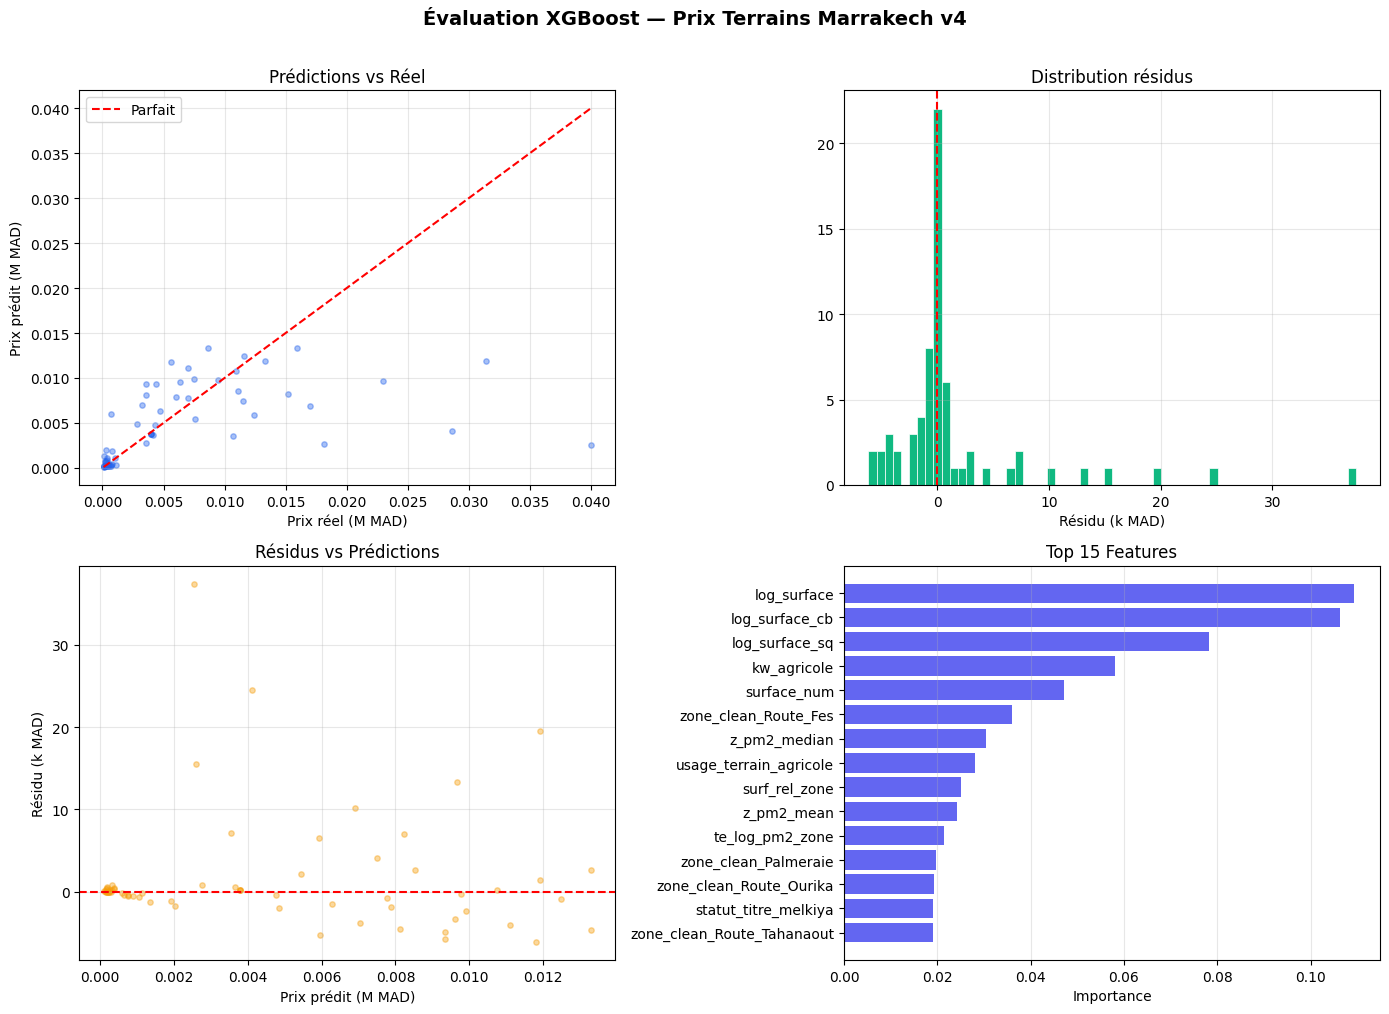

In [32]:
residuals = y_true_mad - y_pred_mad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Évaluation XGBoost — Prix Terrains Marrakech v4", fontsize=14, fontweight="bold", y=1.01)

ax = axes[0,0]
ax.scatter(y_true_mad/1e6, y_pred_mad/1e6, alpha=0.4, s=15, color="#2563EB")
lims=[min(y_true_mad.min(),y_pred_mad.min())/1e6, max(y_true_mad.max(),y_pred_mad.max())/1e6]
ax.plot(lims,lims,"r--",lw=1.5,label="Parfait"); ax.legend()
ax.set_xlabel("Prix réel (M MAD)"); ax.set_ylabel("Prix prédit (M MAD)")
ax.set_title("Prédictions vs Réel"); ax.grid(True,alpha=0.3)

ax = axes[0,1]
ax.hist(residuals/1e3,bins=60,color="#10B981",edgecolor="white",lw=0.5)
ax.axvline(0,color="red",ls="--",lw=1.5)
ax.set_xlabel("Résidu (k MAD)"); ax.set_title("Distribution résidus"); ax.grid(True,alpha=0.3)

ax = axes[1,0]
ax.scatter(y_pred_mad/1e6,residuals/1e3,alpha=0.4,s=15,color="#F59E0B")
ax.axhline(0,color="red",ls="--",lw=1.5)
ax.set_xlabel("Prix prédit (M MAD)"); ax.set_ylabel("Résidu (k MAD)")
ax.set_title("Résidus vs Prédictions"); ax.grid(True,alpha=0.3)

ax = axes[1,1]
pre = pipeline_final.named_steps["pre"]; mdl = pipeline_final.named_steps["model"]
try:
    fn = (list(pre.transformers_[0][2])+list(pre.transformers_[1][2])+
          list(pre.transformers_[2][1].get_feature_names_out(cat_cols)))
except:
    fn = [f"f{i}" for i in range(mdl.n_features_in_)]
imp=mdl.feature_importances_; top=min(15,len(fn)); idx=np.argsort(imp)[-top:]
ax.barh([fn[i] for i in idx],imp[idx],color="#6366F1")
ax.set_xlabel("Importance"); ax.set_title(f"Top {top} Features"); ax.grid(True,alpha=0.3,axis="x")

plt.tight_layout()
plt.savefig("terrain_model_evaluation.png",dpi=150,bbox_inches="tight"); plt.show()


## 9. Analyse erreurs

In [33]:
erreur_pct = np.abs((y_true_mad - y_pred_mad) / y_true_mad) * 100
df_err = X_test[ALL_FEATURES].copy()
df_err["prix_reel"]   = y_true_mad
df_err["prix_predit"] = y_pred_mad
df_err["erreur_pct"]  = erreur_pct
df_err["surface"]     = df.loc[X_test.index, "surface_num"].values

# FIX : zone_clean au lieu de quartier_clean
print("=== MAPE par zone ===")
print(df_err.groupby("zone_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== MAPE par usage_terrain ===")
print(df_err.groupby("usage_terrain")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

df_err["tranche"] = pd.cut(df_err["surface"],
    bins=[0, 300, 1000, 5000, 20000, 999999],
    labels=["<300m²","300-1k","1k-5k","5k-20k",">20k"])
print("\n=== MAPE par tranche de surface ===")
print(df_err.groupby("tranche", observed=True)["erreur_pct"]
      .agg(["mean","count","median"]).round(1))

print("\n=== Précision par seuil ===")
for s in [10, 20, 30, 50]:
    print(f"  Erreur <= {s:2d}% : {(erreur_pct <= s).mean()*100:.1f}% des cas")

=== MAPE par zone ===
                       mean  count
zone_clean                        
Palmeraie            1032.9      1
Route_Safi            216.0      2
Autre                  94.7     23
Route_Casa             92.2     12
Route_Fes              86.3      6
Route_Amizmiz          71.4      1
chrifia                64.2      2
Route_Ourika           63.6      9
Marrakech_centre       43.8      1
sidi abdellah ghiat    18.0      4
Targa                  12.6      1
Route_Tahanaout        12.6      4

=== MAPE par usage_terrain ===
                mean  count
usage_terrain              
autre          118.3     46
golf            52.2      1
agricole        38.2      8
immeuble        38.0     11

=== MAPE par tranche de surface ===
          mean  count  median
tranche                      
<300m²    56.0     18    42.6
300-1k    84.5     22    49.0
1k-5k    187.4      9    85.6
5k-20k   135.8     11    45.9
>20k      28.6      6    16.3

=== Précision par seuil ===
  Erreur <= 

## 10. Sauvegarde

In [34]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

# Sauvegarder pipeline + infos nécessaires pour predict_price
encode_stats = {
    "z_pm2_med"  : df.groupby("zone_clean")["pm2"].median().to_dict(),
    "z_pm2_mean" : df.groupby("zone_clean")["pm2"].mean().to_dict(),
    "q_pm2_med"  : df.groupby("quartier_clean")["pm2"].median().to_dict(),
    "z_surf_med" : df.groupby("zone_clean")["surface_num"].median().to_dict(),
    "fp2"        : float(df["pm2"].median()),
    "fs"         : float(df["surface_num"].median()),
    "all_features": ALL_FEATURES,
    "num_cols"   : num_cols,
    "bin_cols"   : bin_cols,
    "cat_cols"   : cat_cols,
}
joblib.dump({"pipeline": pipeline_final, "stats": encode_stats}, MODEL_PATH)
print(f"✅ Modèle sauvegardé       → {MODEL_PATH}")

metadata = {
    "date"           : datetime.now().strftime("%Y-%m-%d"),
    "version"        : "v4_optuna",
    "modele"         : "XGBRegressor",
    "type_bien"      : "terrain_vente",
    "target"         : "log(prix_total)",
    "n_lignes_train" : len(X_train),
    "n_lignes_test"  : len(X_test),
    "n_features"     : len(ALL_FEATURES),
    "n_zones"        : int(df["zone_clean"].nunique()),
    "sources"        : df["source_clean"].value_counts().to_dict() if "source_clean" in df.columns else {},
    "features_cles"  : ["log_surface","z_pm2_median","log_prix_estime","terrain_quality","kw_facade","kw_immeuble","kw_agricole"],
    "metriques_test" : {
        "R2"   : round(metrics_final["R²"],4),
        "MAE"  : round(metrics_final["MAE (MAD)"],0),
        "RMSE" : round(metrics_final["RMSE (MAD)"],0),
        "MAPE" : round(metrics_final["MAPE (%)"],2),
    },
    "hyperparametres": study.best_params,
    "affichage_site" : "Fourchette ±40% obligatoire pour les terrains",
    "formule"        : "prix_min = prix_estime × 0.60 | prix_max = prix_estime × 1.60",
}
with open(META_PATH,"w",encoding="utf-8") as f:
    json.dump(metadata,f,ensure_ascii=False,indent=2)
print(f"✅ Métadonnées sauvegardées → {META_PATH}")

df.to_csv(CLEAN_PATH, index=False)
print(f"✅ Dataset sauvegardé      → {CLEAN_PATH}")

print("\n"+"═"*55)
print("  RÉSUMÉ FINAL — TERRAIN VENTE v4")
print("═"*55)
print(f"  Données          : {len(df):,} terrains | {df['zone_clean'].nunique()} zones")
print(f"  Features         : {len(ALL_FEATURES)}")
print(f"  R² (test)        : {metrics_final['R²']:.4f}")
print(f"  MAE (test)       : {metrics_final['MAE (MAD)']:,.0f} MAD")
print(f"  MAPE (test)      : {metrics_final['MAPE (%)']:.2f} %")
print(f"  CV R² Optuna     : {study.best_value:.4f}")
print("═"*55)
print(f"\n  Appartements : R²=0.73, MAPE=19% ✅  Prix fixe")
print(f"  Villas       : R²=0.65, MAPE=26% ⚠️   Fourchette ±30%")
print(f"  Terrains     : R²={metrics_final['R²']:.2f}, MAPE={metrics_final['MAPE (%)']:.0f}% ⚠️   Fourchette ±40%")


✅ Modèle sauvegardé       → ../../model_training/models/xgb_terrain_vente.pkl
✅ Métadonnées sauvegardées → ../../model_training/models/xgb_terrain_vente_metadata.json
✅ Dataset sauvegardé      → ../../data/cleaned_data/vente/terrain_vente_final.csv

═══════════════════════════════════════════════════════
  RÉSUMÉ FINAL — TERRAIN VENTE v4
═══════════════════════════════════════════════════════
  Données          : 328 terrains | 14 zones
  Features         : 34
  R² (test)        : 0.2303
  MAE (test)       : 3,326 MAD
  MAPE (test)      : 94.20 %
  CV R² Optuna     : 0.7558
═══════════════════════════════════════════════════════

  Appartements : R²=0.73, MAPE=19% ✅  Prix fixe
  Villas       : R²=0.65, MAPE=26% ⚠️   Fourchette ±30%
  Terrains     : R²=0.23, MAPE=94% ⚠️   Fourchette ±40%


## 11. Fonction de prédiction

In [35]:
def predict_terrain(pipeline_saved, terrain: dict) -> dict:
    """
    Prédit le prix d'un terrain avec fourchette ±40%.
    
    terrain dict doit contenir au minimum :
        surface_num, zone_clean, quartier_clean, usage_terrain
    """
    stats     = pipeline_saved["stats"]
    pipeline  = pipeline_saved["pipeline"]
    
    t = terrain.copy()
    t["log_surface"]    = np.log(t["surface_num"])
    t["log_surface_sq"] = t["log_surface"]**2
    t["log_surface_cb"] = t["log_surface"]**3
    
    zm = stats["z_pm2_med"].get(t.get("zone_clean","autre_zone"), stats["fp2"])
    qm = stats["q_pm2_med"].get(t.get("quartier_clean","Autre"),  stats["fp2"])
    sm = stats["z_surf_med"].get(t.get("zone_clean","autre_zone"), stats["fs"])
    
    t["z_pm2_median"]    = zm
    t["z_pm2_mean"]      = stats["z_pm2_mean"].get(t.get("zone_clean","autre_zone"), stats["fp2"])
    t["q_pm2_median"]    = qm
    t["prix_estime"]     = t["surface_num"] * zm
    t["log_prix_estime"] = np.log(max(t["prix_estime"], 1))
    t["log_surf_x_pm2"]  = t["log_surface"] * zm / 1e3
    t["surf_rel_zone"]   = t["surface_num"] / sm
    t["te_log_pm2_zone"] = np.log(max(zm, 1))
    
    df_in = pd.DataFrame([t])
    all_f = stats["all_features"]
    for c in all_f:
        if c not in df_in.columns:
            df_in[c] = 0
    
    prix_pred = np.exp(pipeline.predict(df_in[all_f])[0])
    prix_min  = prix_pred * 0.60
    prix_max  = prix_pred * 1.60
    pm2_pred  = prix_pred / t["surface_num"]
    
    print(f"💰 Prix estimé   : {prix_pred:,.0f} MAD ({prix_pred/10.8:,.0f} EUR)")
    print(f"   Fourchette    : {prix_min:,.0f} – {prix_max:,.0f} MAD")
    print(f"   Prix/m²       : {pm2_pred:,.0f} MAD/m²")
    print(f"   Surface       : {t['surface_num']:,.0f} m²")
    return {"prix_estime": prix_pred, "prix_min": prix_min, "prix_max": prix_max, "pm2": pm2_pred}

# Exemple
saved = joblib.load(MODEL_PATH)
terrain_exemple = {
    "surface_num"     : 1500,
    "zone_clean"      : "targa",
    "quartier_clean"  : "Targa",
    "usage_terrain"   : "autre",
    "statut_titre"    : "titre_foncier",
    "source_clean"    : "avito",
    "surface_cat"     : "moyen",
    "kw_immeuble":0,"kw_agricole":0,"kw_golf":0,"kw_villa_zone":0,
    "kw_resid":1,"kw_facade":0,"kw_projet":0,"kw_constructible":1,
    "kw_plat":1,"kw_urgent":0,"kw_viabilise":0,"kw_industriel":0,
    "kw_tf":1,"kw_melk":0,"terrain_quality":3,
    "piscine":0,"parking":0,"jardin":0,"securite":0,"vue":0,"neuf":0,
}
result = predict_terrain(saved, terrain_exemple)


💰 Prix estimé   : 951 MAD (88 EUR)
   Fourchette    : 571 – 1,522 MAD
   Prix/m²       : 1 MAD/m²
   Surface       : 1,500 m²
